# 🚢 Titanic Survival Prediction

## Machine Learning Classification Project

This project explores the Titanic dataset to analyze passenger survival patterns and build machine learning models capable of predicting survival outcomes.

The project follows a professional Data Science workflow including:

- Data Cleaning
- Feature Engineering
- Exploratory Data Analysis (EDA)
- Logistic Regression
- Random Forest
- Model Evaluation
- Feature Importance Analysis

---

## Technologies Used

- Python
- Pandas
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

---

## Project Goal

The goal is not only to build predictive models, but also to understand the relationships between passenger characteristics and survival probability.

In [26]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

from data.load_data import cargar_datos
from data.clean_data import revisar_nulos, imputar_datos
from features.build_features import agregar_tamano_familia

from visualization.plots import (
    plot_survival_by_family,
    plot_survival_by_sex,
    plot_survival_by_class,
    plot_age_distribution,
    plot_age_boxplot,
    plot_correlation_heatmap,
    plot_feature_importance
)

from models.train_model import entrenar_modelo
from models.random_forest_model import entrenar_random_forest
from models.evaluate_model import evaluar_modelo

# Load Dataset

In [27]:
df = cargar_datos('../data/titanic.csv')

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Dataset Overview

Before cleaning and modeling the data, it is important to understand:

- Dataset dimensions
- Data types
- Missing values
- General structure

In [28]:
print(f'Rows: {df.shape[0]}')
print(f'Columns: {df.shape[1]}')

Rows: 891
Columns: 12


In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [30]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [31]:
revisar_nulos(df)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# 🧹 Data Cleaning

The dataset contains missing values in several variables.

Cleaning strategy:

- `Age` → median imputation
- `Embarked` → mode imputation
- `Cabin` → removed due to excessive missing values

In [32]:
df = imputar_datos(df)

In [33]:
revisar_nulos(df)

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

# Feature Engineering

A new variable called `FamilySize` is created to represent the total family members traveling together.

This feature combines:

- `SibSp`
- `Parch`

In [34]:
df = agregar_tamano_familia(df)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0


# Exploratory Data Analysis (EDA)

## Survival Rate by Family Size

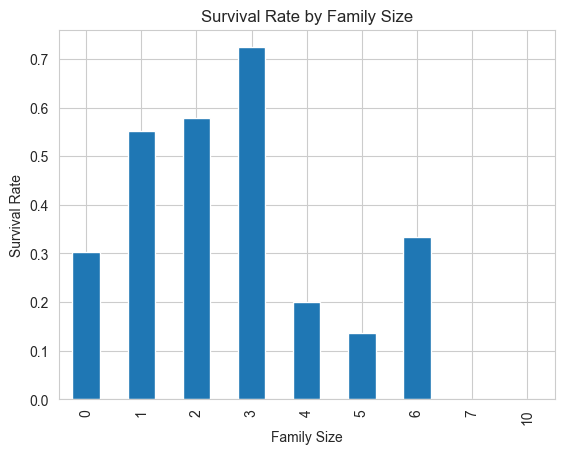

In [35]:
plot_survival_by_family(df)

### Observation

Passengers traveling with small families showed different survival patterns compared to passengers traveling alone or in large groups.

## Survival Rate by Sex

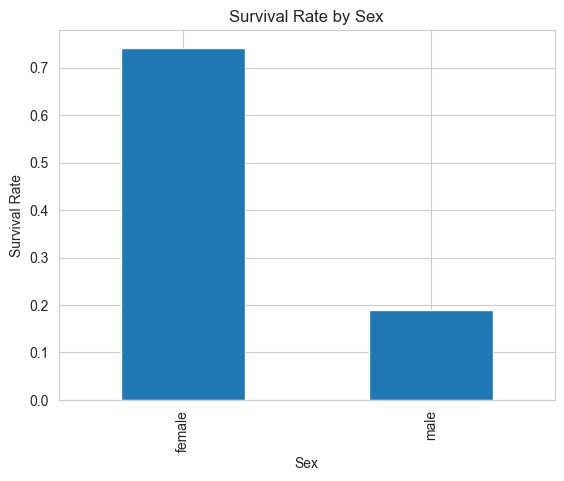

In [36]:
plot_survival_by_sex(df)

### Insight

Female passengers had a significantly higher survival rate compared to male passengers.

This suggests that sex is likely one of the strongest predictive variables in the dataset.

## Survival Rate by Passenger Class

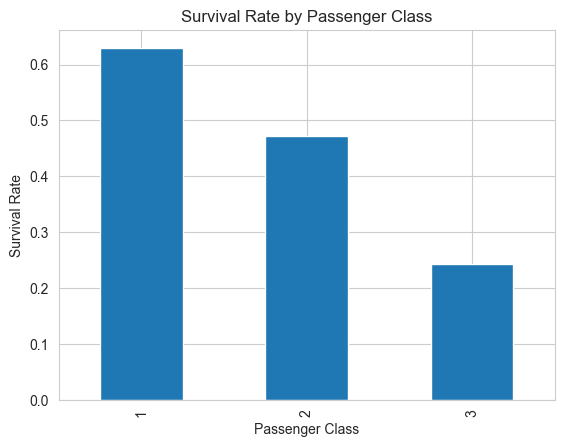

In [37]:
plot_survival_by_class(df)

### Insight

Passengers traveling in higher classes had greater survival probabilities.

This may reflect differences in cabin location, access to lifeboats, or social priority during evacuation.

## Survival Rate by Family Size

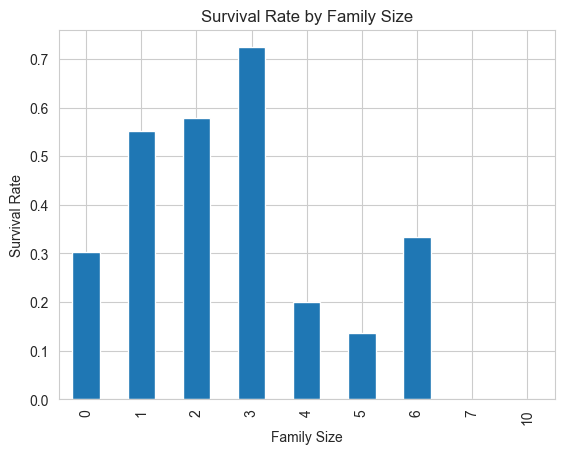

In [38]:
plot_survival_by_family(df)

### Insight

Passengers traveling in very large groups or completely alone appeared to have lower survival rates.

## Age Distribution

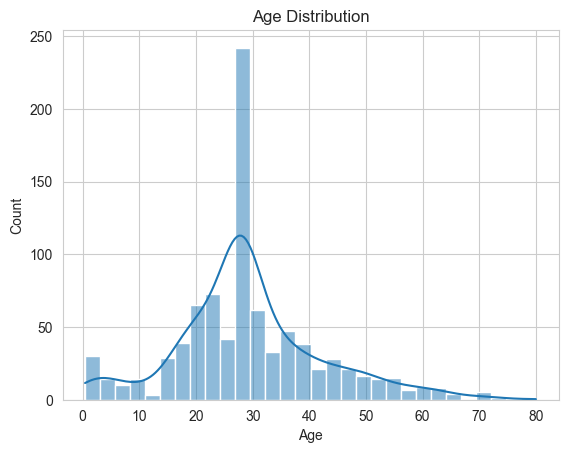

In [39]:
plot_age_distribution(df)

### Insight

Most passengers were concentrated in young adult age ranges, with fewer elderly passengers represented in the dataset.

## Age Boxplot

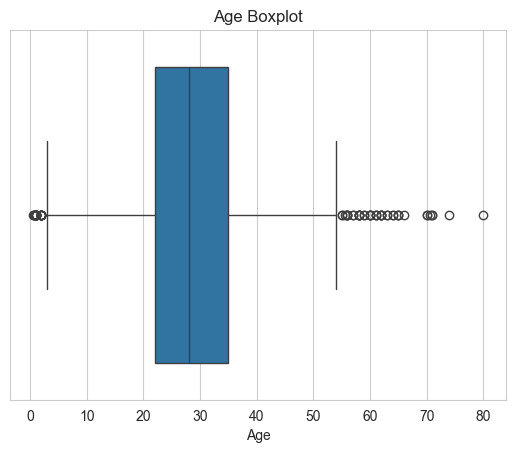

In [40]:
plot_age_boxplot(df)

### Insight

The boxplot reveals the presence of several age outliers, particularly among older passengers.

## Correlation Heatmap

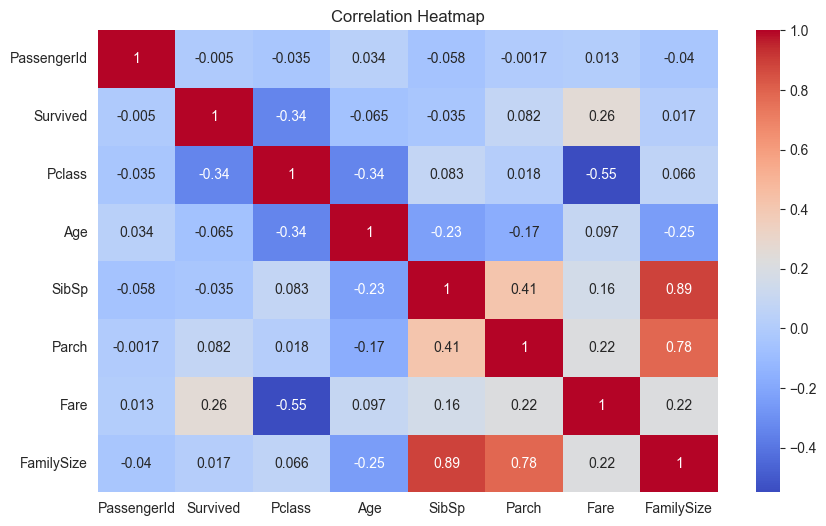

In [41]:
plot_correlation_heatmap(df)

### Insight

Variables such as passenger class, fare, and family size show meaningful relationships with survival probability.

# Logistic Regression Model

Logistic Regression is used as a baseline classification model.

This model is:
- Fast
- Interpretable
- Commonly used for binary classification

In [42]:
modelo, y_test, predictions = entrenar_modelo(df)

Accuracy: 0.8044692737430168


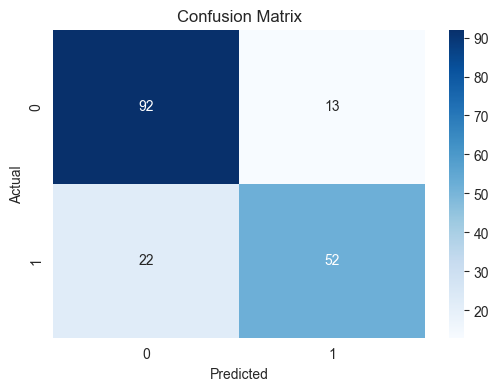

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       105
           1       0.80      0.70      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [43]:
evaluar_modelo(y_test, predictions)

### Model Interpretation

The Logistic Regression model achieved solid performance and provided a strong baseline for future model comparisons.

# Random Forest Model

Random Forest is an ensemble learning algorithm that combines multiple decision trees.

Advantages:
- Handles non-linear relationships
- Reduces overfitting
- Often performs well on tabular datasets

In [44]:
rf_model, X, y_test, predictions = entrenar_random_forest(df)

Random Forest Accuracy: 0.8044692737430168


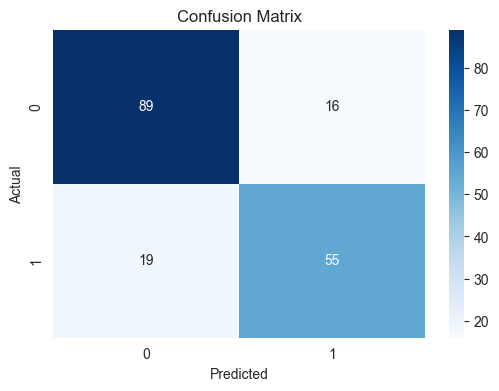

              precision    recall  f1-score   support

           0       0.82      0.85      0.84       105
           1       0.77      0.74      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.80      0.80      0.80       179



In [45]:
evaluar_modelo(y_test, predictions)

### Model Interpretation

Random Forest improved predictive flexibility and captured more complex interactions between variables.

# Feature Importance

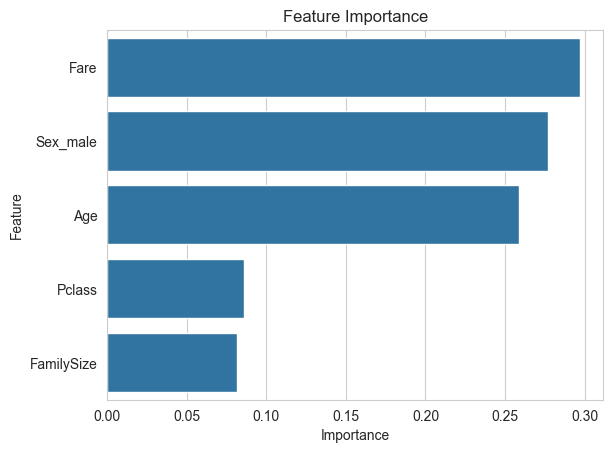

In [46]:
plot_feature_importance(rf_model, X)

### Insight

Feature importance analysis indicates that variables such as sex, fare, passenger class, and age strongly influenced model predictions.

# Pipeline Profesional con Scikit-Learn

In [47]:
from models.pipeline_model import entrenar_pipeline

In [48]:
pipeline_model, y_test, predictions = entrenar_pipeline(df)

Pipeline Accuracy: 0.7988826815642458


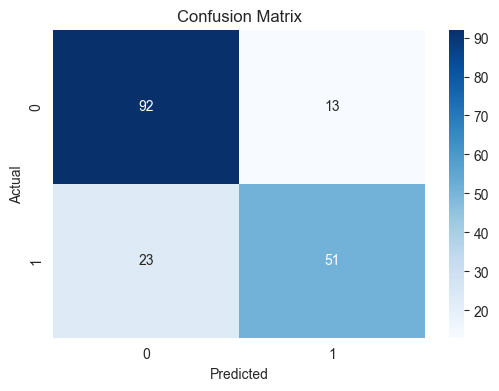

              precision    recall  f1-score   support

           0       0.80      0.88      0.84       105
           1       0.80      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [49]:
evaluar_modelo(y_test, predictions)

# Hyperparameter Tuning

Best Parameters:
{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}
Best Score:
0.8356150891362158


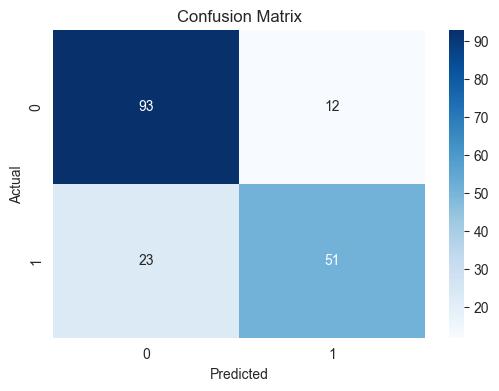

              precision    recall  f1-score   support

           0       0.80      0.89      0.84       105
           1       0.81      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [53]:
from models.tune_random_forest import (
    optimizar_random_forest
)

best_model, X_test, y_test = (
    optimizar_random_forest(df)
)

predictions = best_model.predict(X_test)

evaluar_modelo(
    y_test,
    predictions
)

# Final Conclusions

## Key Findings

- Female passengers had significantly higher survival rates.
- Passenger class strongly influenced survival probability.
- Feature engineering improved model usefulness.
- Logistic Regression provided a reliable baseline model.
- Random Forest captured more complex patterns and relationships.

---

## Technical Skills Demonstrated

This project demonstrates:

- Data Cleaning
- Exploratory Data Analysis
- Data Visualization
- Feature Engineering
- Machine Learning Classification
- Model Evaluation
- Feature Importance Analysis
- Modular Project Architecture
